# house pricing predictore

In [2]:
# Basic data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Train/test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Pipelines
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## get data

In [3]:

housing = fetch_california_housing(as_frame=True)

df_copy = housing.data.copy()
df_copy["MedHouseVal"] = housing.target
df_copy["price"] = df_copy["MedHouseVal"] * 100000

df_copy.head()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,342200.0


## dataset visualisation

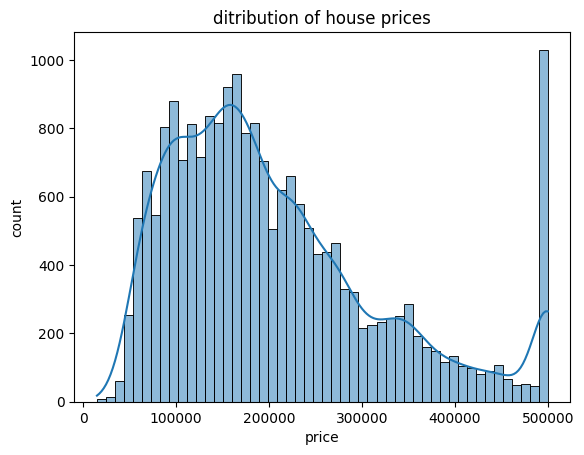

In [4]:
plt.Figure(figsize=(8,5))
sns.histplot(df_copy["price"],bins=50,kde=True)
plt.title("ditribution of house prices")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

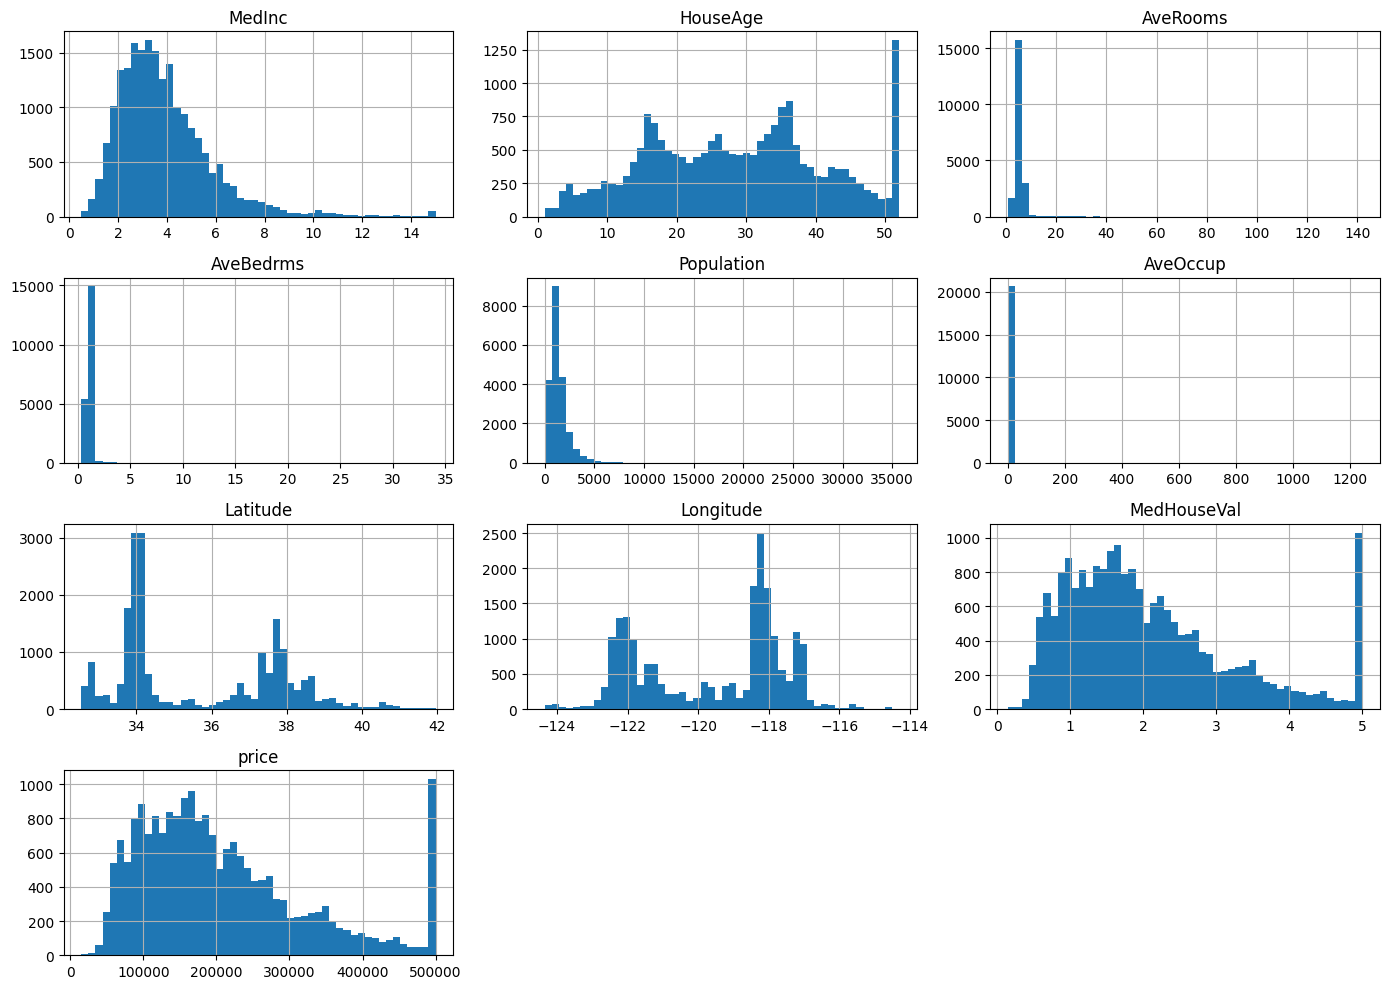

In [5]:
df_copy.hist(figsize=(14,10),bins=50)
plt.tight_layout()
plt.show()

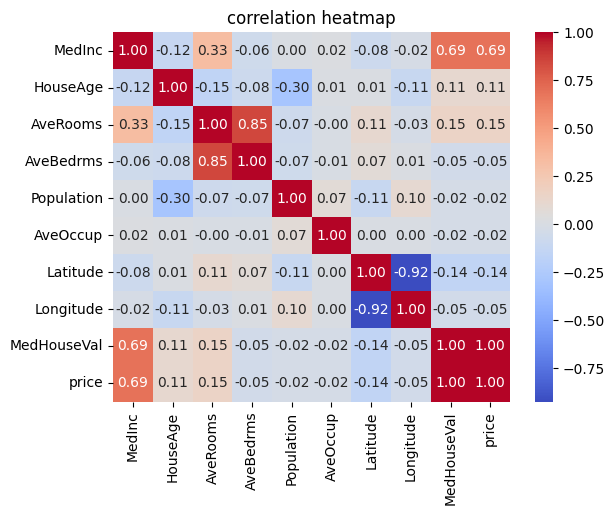

In [6]:
plt.Figure(figsize=(10,7))
sns.heatmap(df_copy.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation heatmap")
plt.show()

## data cleaning

In [7]:
f'missing values : {df_copy.isnull().sum()}'

'missing values : MedInc         0\nHouseAge       0\nAveRooms       0\nAveBedrms      0\nPopulation     0\nAveOccup       0\nLatitude       0\nLongitude      0\nMedHouseVal    0\nprice          0\ndtype: int64'

In [8]:
x = df_copy.drop(["MedHouseVal","price"],axis=1)
y = df_copy["price"]

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# models training

### linear regression

In [10]:
model1 = LinearRegression()
model1.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model1.predict(x_test)

### evaluation

MAE: $53,320.01
RMSE: $74,558.14
R² Score: 0.5758
R² as percentage: 57.58%


,Actual Price,Predicted Price,Difference
20046,47700.0,71912.284160,-24212.284160
3024,45800.0,176401.657066,-130601.657066
15663,500001.0,270965.883343,229035.116657
20484,218600.0,283892.593018,-65292.593018
9814,278000.0,260465.725181,17534.274819
13311,158700.0,201175.367325,-42475.367325
7113,198200.0,264550.004938,-66350.004938
7668,157500.0,216875.532129,-59375.532129
18246,340000.0,274074.644114,65925.355886
5723,446600.0,391561.472503,55038.527497


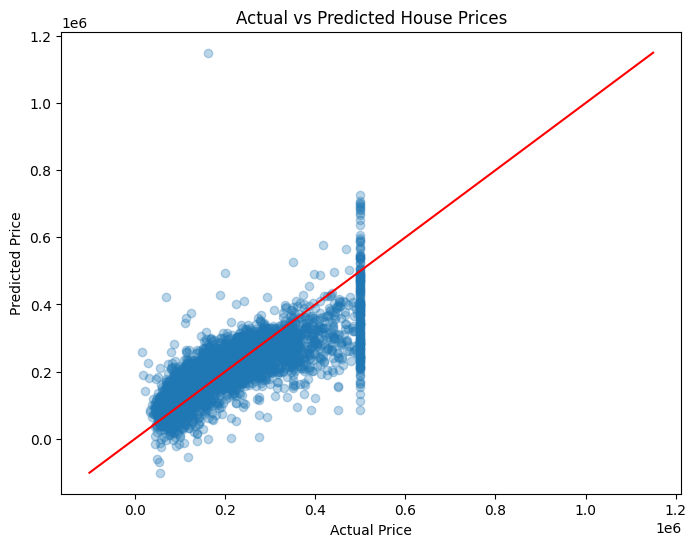

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"R² as percentage: {r2 * 100:.2f}%")

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred,
    "Difference": y_test - y_pred
})

display(results.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## random forest

In [13]:
model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(x_train,y_train)
model2_pred = model2.predict(x_test)


In [14]:
mae_rf = mean_absolute_error(y_test,model2_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test,model2_pred))
r2_rf = r2_score(y_test,model2_pred)

### evaluation

In [15]:
f'MAE : ${mae_rf:,.2f}'

'MAE : $32,811.68'

In [16]:
f'RMSE : ${rmse_rf:,.2f}'

'RMSE : $50,710.38'

In [17]:
f'R² : ${r2_rf:,.2f}'

'R² : $0.80'

In [18]:

f'R² as percentage : ${r2_rf * 100:.2f}%'

'R² as percentage : $80.38%'

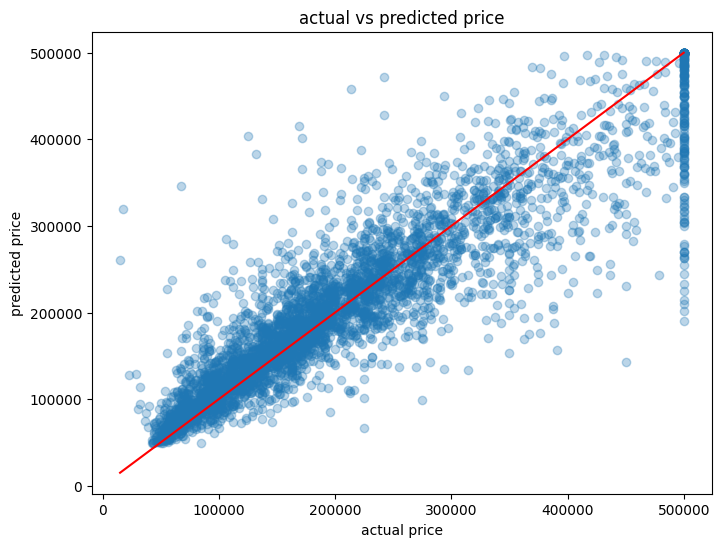

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,model2_pred,alpha=0.3)

min_price = min(y_test.min(),model2_pred.min())
max_price = max(y_test.max(),model2_pred.max())

plt.plot([min_price,max_price],[min_price,max_price],color='red')

plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted price")

plt.show()

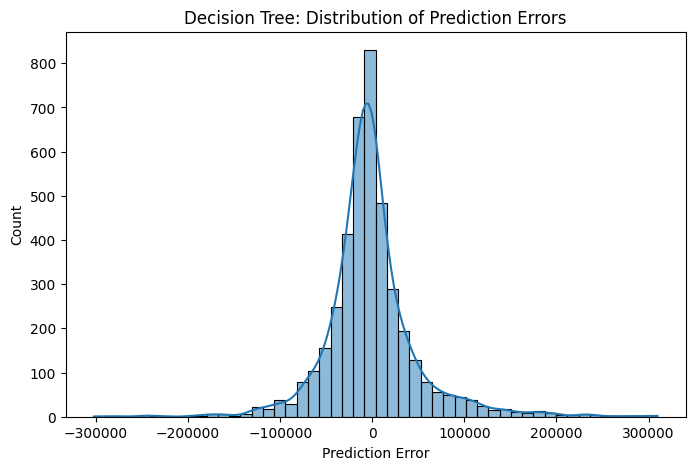

In [21]:

residuals = y_test - model2_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True)

plt.xlabel("Prediction Error")
plt.title("Decision Tree: Distribution of Prediction Errors")
plt.show()


## random forest

In [22]:
model3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model3.fit(x_train,y_train)

model3_pred = model3.predict(x_test)

In [23]:
mar_rf = mean_absolute_error(y_test,model3_pred)
f'MAE : ${mar_rf:,.2f}'

'MAE : $32,811.68'

In [24]:
rmse_rf = np.sqrt(mean_squared_error(y_test,model3_pred))
f'RMSE : ${rmse_rf:,.2f}'

'RMSE : $50,710.38'

In [25]:
r2_rf = r2_score(y_test,model3_pred)
f'R² : ${r2_rf:,.2f}'

'R² : $0.80'

### visualisation

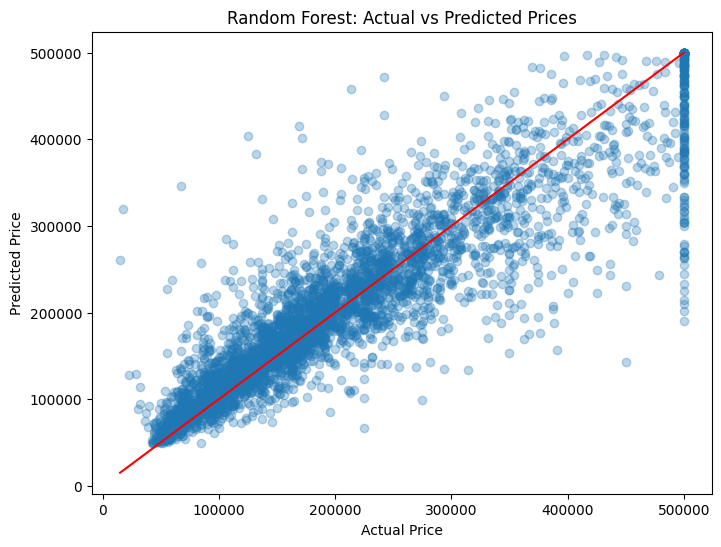

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, model3_pred, alpha=0.3)

min_price = min(y_test.min(), model3_pred.min())
max_price = max(y_test.max(), model3_pred.max())

plt.plot([min_price, max_price], [min_price, max_price], color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")

plt.show()

In [27]:
n_trees_list = [10, 25, 50, 100, 150, 200]

rf_results = []

for n in n_trees_list:
    model = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    model.fit(x_train, y_train)
    preds = model.predict(x_test)

    rf_results.append({
        "n_estimators": n,
        "R2 Score": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds)
    })

rf_results_df = pd.DataFrame(rf_results)

rf_results_df

,n_estimators,R2 Score,MAE
0,10,0.783197,34978.865359
1,25,0.799322,33614.360853
2,50,0.803224,32981.390489
3,100,0.803760,32811.677875
4,150,0.805001,32754.520893
5,200,0.805698,32681.977769


## gradiant boosting

In [28]:
model4 = GradientBoostingRegressor(
    random_state=42
)

model4.fit(x_train,y_train)

model4_pred = model4.predict(x_test)

In [29]:
mae_gb = mean_absolute_error(y_test,model4_pred)
f'MAE : ${mae_gb:,.2f}'

'MAE : $37,164.26'

In [31]:
rmse_gb = np.sqrt(mean_squared_error(y_test,model4_pred))
f'RMSE : ${rmse_gb:,.2f}'

'RMSE : $54,221.52'

In [32]:
r2_gb = r2_score(y_test,model4_pred)
f'R² : ${r2_gb:,.2f}'

'R² : $0.78'

### visualisation

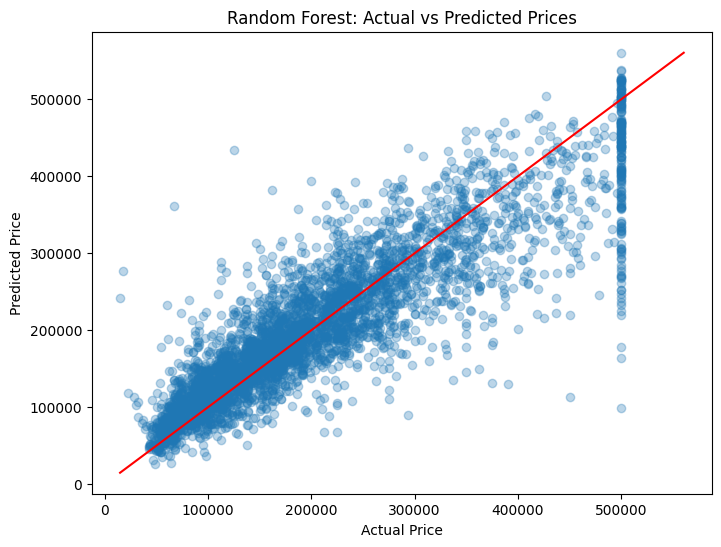

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, model4_pred, alpha=0.3)

min_price = min(y_test.min(), model4_pred.min())
max_price = max(y_test.max(), model4_pred.max())

plt.plot([min_price, max_price], [min_price, max_price], color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")

plt.show()

# comparing all the models

In [36]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for model_name, model in models.items():
    # Train model
    model.fit(x_train, y_train)
    
    # Predict
    predictions = model.predict(x_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "R2 Percentage": r2 * 100
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,Model,MAE,RMSE,R2 Score,R2 Percentage
2,Random Forest,32811.677875,50710.381959,0.803760,80.376029
3,Gradient Boosting,37164.256904,54221.520162,0.775645,77.564460
1,Decision Tree,45498.174903,70671.232541,0.618865,61.886532
0,Linear Regression,53320.013050,74558.138301,0.575788,57.578771


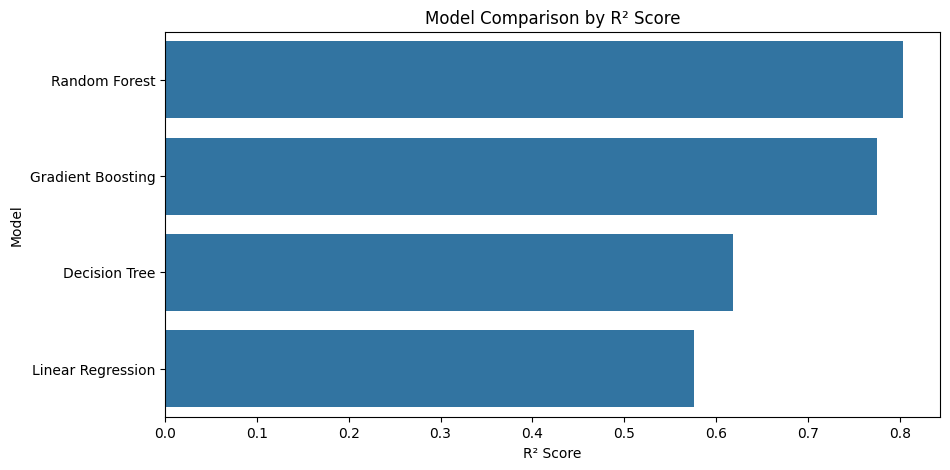

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("Model Comparison by R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

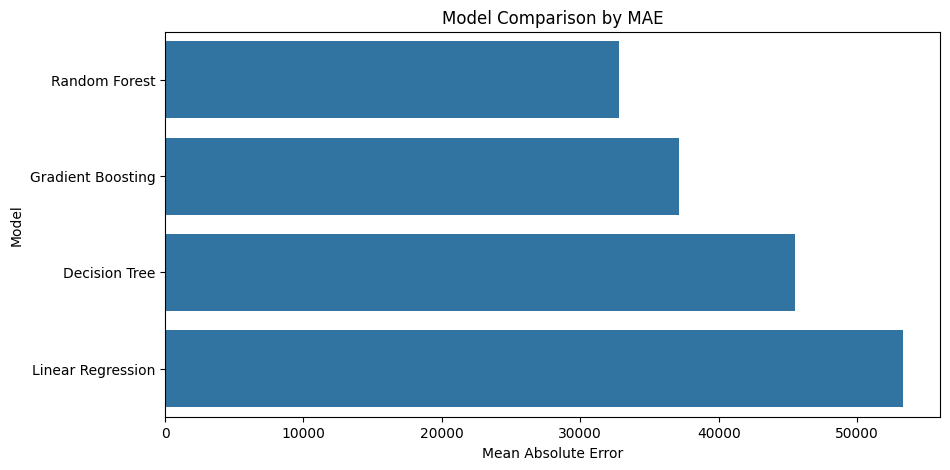

In [38]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df.sort_values(by="MAE", ascending=True),
    x="MAE",
    y="Model"
)

plt.title("Model Comparison by MAE")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")

plt.show()

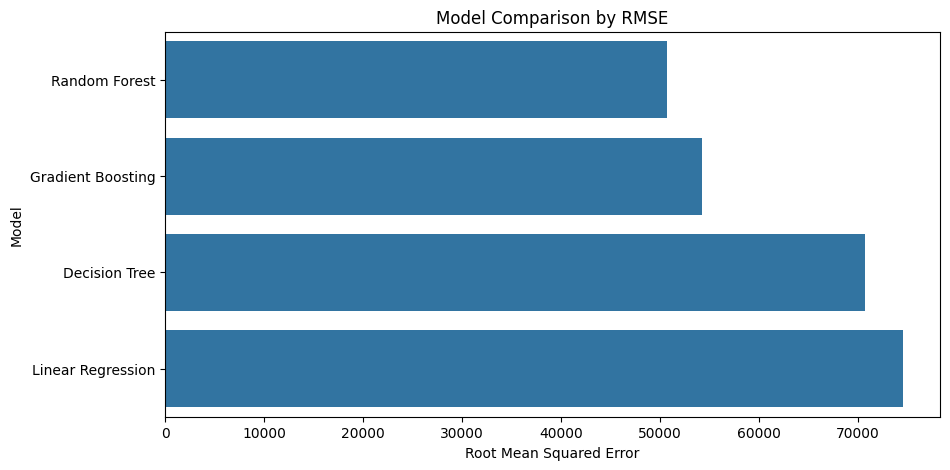

In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df.sort_values(by="RMSE", ascending=True),
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison by RMSE")
plt.xlabel("Root Mean Squared Error")
plt.ylabel("Model")

plt.show()

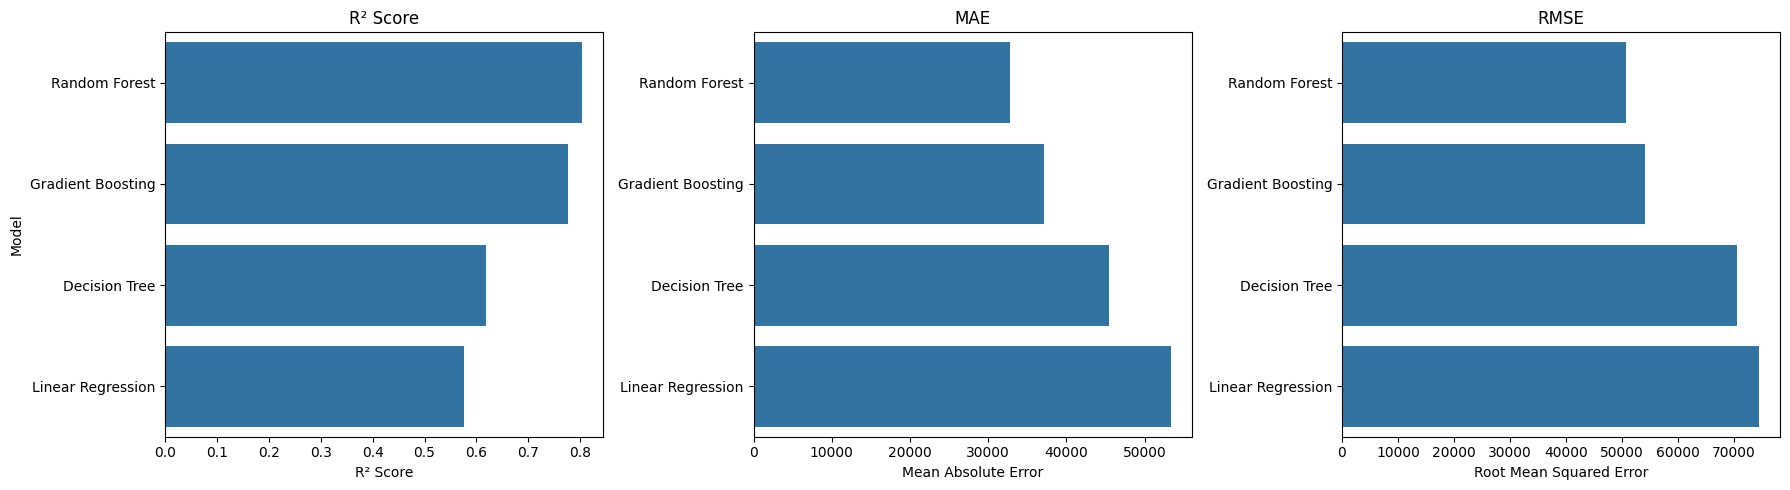

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=results_df.sort_values(by="R2 Score", ascending=False),
    x="R2 Score",
    y="Model",
    ax=axes[0]
)
axes[0].set_title("R² Score")
axes[0].set_xlabel("R² Score")
axes[0].set_ylabel("Model")

sns.barplot(
    data=results_df.sort_values(by="MAE", ascending=True),
    x="MAE",
    y="Model",
    ax=axes[1]
)
axes[1].set_title("MAE")
axes[1].set_xlabel("Mean Absolute Error")
axes[1].set_ylabel("")

sns.barplot(
    data=results_df.sort_values(by="RMSE", ascending=True),
    x="RMSE",
    y="Model",
    ax=axes[2]
)
axes[2].set_title("RMSE")
axes[2].set_xlabel("Root Mean Squared Error")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

we can clearly see that the random forest algorithm has reached the best results since it has scored the highest R² score , and the lowest MAE and RMSE , while linear regression was the lowest performer between all the 4 algorithms .
the closest one to the random forest was the gradient boosting algorithm